# DPO on ECCV
### libraries

In [ ]:
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
import os

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

# Check what's at the top level
print(os.listdir("/content/drive/"))

# Then go deeper
print(os.listdir("/content/drive/MyDrive/"))

# If you have shared drives:
shared = "/content/drive/Shareddrives/"
if os.path.exists(shared):
    print("Shared drives:", os.listdir(shared))
else:
    print("No Shareddrives folder found — folder may be a shortcut in MyDrive")

['MyDrive', '.shortcut-targets-by-id', '.Trash-0', '.Encrypted']
['Personal', 'Colab Notebooks', 'Candidati appartamento.gsheet', 'university', 'GYBE.zip', 'CV_project_Shar']
No Shareddrives folder found — folder may be a shortcut in MyDrive


In [ ]:
import sys

# Add the directory containing 'colorization' and 'dpo_train.py' to the Python path
sys.path.append("/content/drive/MyDrive/CV_project_Shar/")

In [ ]:
import os

os.chdir("/content/drive/MyDrive/CV_project_Shar/")  # do this before the import
print(os.getcwd())

/content/drive/.shortcut-targets-by-id/1h4wbWyTZnHCTV-D6544VDgu3M3YYX8NV/CV_project_Shar


In [ ]:
# eccv16 specific files and models

sys.path.append(
    "/content/drive/MyDrive/CV_project_Shar/"
)  # Ensure path is set for this cell
print("Current sys.path:", sys.path)  # Verify sys.path
print(os.listdir("/content/drive/MyDrive/CV_project_Shar/"))
from colorization import *

"""colorizers contains several useful tools:
- the model base structure, that we will fine tune on
- functions usable for pre/post processing
"""
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from dpo_train import *  # dpo_train contains DPO training functions
import pandas as pd
import ast
import os
import re
import subprocess
from pathlib import Path
from sklearn.decomposition import PCA
from PIL import Image
import numpy as np
from skimage import color
from IPython import embed

Current sys.path: ['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/content/drive/MyDrive/CV_project_Shar/', '/content/drive/MyDrive/CV_project_Shar/']
['DPO on ECCV LB.ipynb', 'test_256.zip', 'val_256.zip', 'DPO_dataset', 'DPO_Results.py', 'colorization', '__pycache__', 'DPO on ECCV.ipynb', 'pts_in_hull.npy', 'dpo_model_parameters.pth', 'LoRA.py', 'dpo_model_parameters_13_05.pth', 'FinalResults.csv', 'FinalResults_FAKE.csv', 'dpo_model_merged.pth', 'dpo_model_parameters_14_05.pth', 'Test post training.ipynb', 'dpo_trained_020526.pth', 'DPO_lora_0.3_1e-05_1505.pth', 'dpo_train.py']


In [ ]:
import os

# List contents of the directory where colorizers is expected
print(os.listdir("/content/drive/MyDrive/CV_project_Shar/"))

# Also check if 'colorizers' is a directory and contains an __init__.py
colorizers_path = "/content/drive/MyDrive/CV_project_Shar/colorizers"
if os.path.exists(colorizers_path):
    print(f"Contents of {colorizers_path}:")
    print(os.listdir(colorizers_path))
    if os.path.isdir(colorizers_path) and "__init__.py" not in os.listdir(
        colorizers_path
    ):
        print(
            f"Warning: '{colorizers_path}' is a directory but is missing '__init__.py'. This is required for it to be recognized as a Python package."
        )
else:
    print(
        f"'{colorizers_path}' does not exist. Please ensure the path to 'colorizers' is correct."
    )

['DPO on ECCV LB.ipynb', 'test_256.zip', 'val_256.zip', 'DPO_dataset', 'DPO_Results.py', 'colorization', '__pycache__', 'DPO on ECCV.ipynb', 'pts_in_hull.npy', 'dpo_model_parameters.pth', 'LoRA.py', 'dpo_model_parameters_13_05.pth', 'FinalResults.csv', 'FinalResults_FAKE.csv', 'dpo_model_merged.pth', 'dpo_model_parameters_14_05.pth', 'Test post training.ipynb', 'dpo_trained_020526.pth', 'DPO_lora_0.3_1e-05_1505.pth', 'dpo_train.py']
'/content/drive/MyDrive/CV_project_Shar/colorizers' does not exist. Please ensure the path to 'colorizers' is correct.


In [7]:
"""
!cp -r /content/drive/MyDrive/CV_project_Shar/DPO_dataset/ /content/
!cp /content/drive/MyDrive/CV_project_Shar/FinalResults.csv /content/
"""

'\n!cp -r /content/drive/MyDrive/CV_project_Shar/DPO_dataset/ /content/\n!cp /content/drive/MyDrive/CV_project_Shar/FinalResults.csv /content/\n'

In [ ]:
def load_img(img_path):
    out_np = np.asarray(Image.open(img_path))
    if out_np.ndim == 2:
        out_np = np.tile(out_np[:, :, None], 3)
    return out_np


def resize_img(img, HW=(256, 256), resample=3):
    return np.asarray(Image.fromarray(img).resize((HW[1], HW[0]), resample=resample))


def preprocess_img(img_rgb_orig, HW=(256, 256), resample=3):
    # return original size L and resized L as torch Tensors
    img_rgb_rs = resize_img(img_rgb_orig, HW=HW, resample=resample)

    img_lab_orig = color.rgb2lab(img_rgb_orig)
    img_lab_rs = color.rgb2lab(img_rgb_rs)

    img_l_orig = img_lab_orig[:, :, 0]
    img_l_rs = img_lab_rs[:, :, 0]

    tens_orig_l = torch.Tensor(img_l_orig)[None, None, :, :]
    tens_rs_l = torch.Tensor(img_l_rs)[None, None, :, :]

    return (tens_orig_l, tens_rs_l)


def postprocess_tens(tens_orig_l, out_ab, mode="bilinear"):
    # tens_orig_l 	1 x 1 x H_orig x W_orig
    # out_ab 		1 x 2 x H x W

    HW_orig = tens_orig_l.shape[2:]
    HW = out_ab.shape[2:]

    # call resize function if needed
    if HW_orig[0] != HW[0] or HW_orig[1] != HW[1]:
        out_ab_orig = F.interpolate(out_ab, size=HW_orig, mode="bilinear")
    else:
        out_ab_orig = out_ab

    out_lab_orig = torch.cat((tens_orig_l, out_ab_orig), dim=1)
    return color.lab2rgb(out_lab_orig.data.cpu().numpy()[0, ...].transpose((1, 2, 0)))


def preprocess_img_l_training(img_rgb_orig, HW=(256, 256), resample=3):
    if img_rgb_orig.shape[-1] == 4:
        img_rgb_orig = img_rgb_orig[:, :, :3]

    img_rgb_rs = resize_img(img_rgb_orig, HW=HW, resample=resample)

    img_lab_rs = color.rgb2lab(img_rgb_rs)
    img_l_rs = img_lab_rs[:, :, 0]  # (H, W)

    # (H, W) → (1, H, W) — single channel dim, NO batch dim
    tens_rs_l = torch.Tensor(img_l_rs)[None, :, :]

    return tens_rs_l


def preprocess_img_ab(img_rgb_orig, HW=(256, 256), resample=3):
    if img_rgb_orig.shape[-1] == 4:
        img_rgb_orig = img_rgb_orig[:, :, :3]

    img_rgb_rs = resize_img(img_rgb_orig, HW=HW, resample=resample)

    img_lab_orig = color.rgb2lab(img_rgb_orig)
    img_lab_rs = color.rgb2lab(img_rgb_rs)

    img_ab_orig = img_lab_orig[:, :, 1:]
    img_ab_rs = img_lab_rs[:, :, 1:]

    # (H, W, 2) → (2, H, W) — NO [None] batch dim here
    tens_orig_ab = torch.Tensor(img_ab_orig).permute(2, 0, 1)
    tens_rs_ab = torch.Tensor(img_ab_rs).permute(2, 0, 1)

    return (tens_orig_ab, tens_rs_ab)

### 1: preference dataset import (from FLR HuggingFace space)

In [ ]:
# merge .csv
# Run the called script with arguments
arg1 = "DPO_dataset/test_results_DPO.csv"
subprocess.run(["python3", "DPO_Results.py", arg1])
pref = pd.read_csv("FinalResults.csv")
pref

,Unnamed: 0,ImageID,T_A,T_B,optA_img,optB_img,true_img,baseline_img,humanChoice,rejectionChoice
0,0,0,0.386209,0.881154,DPO_dataset/Img_A/A_0.png,DPO_dataset/Img_B/B_0.png,DPO_dataset/Img_true/Real_0.png,DPO_dataset/Img_baseline/Baseline_0.png,DPO_dataset/Img_A/A_0.png,DPO_dataset/Img_B/B_0.png
1,1,1,0.291687,0.799952,DPO_dataset/Img_A/A_1.png,DPO_dataset/Img_B/B_1.png,DPO_dataset/Img_true/Real_1.png,DPO_dataset/Img_baseline/Baseline_1.png,DPO_dataset/Img_A/A_1.png,DPO_dataset/Img_B/B_1.png
2,2,2,0.250834,0.785077,DPO_dataset/Img_A/A_2.png,DPO_dataset/Img_B/B_2.png,DPO_dataset/Img_true/Real_2.png,DPO_dataset/Img_baseline/Baseline_2.png,NaN,NaN
3,3,3,0.360566,0.850023,DPO_dataset/Img_A/A_3.png,DPO_dataset/Img_B/B_3.png,DPO_dataset/Img_true/Real_3.png,DPO_dataset/Img_baseline/Baseline_3.png,NaN,NaN
4,4,4,0.455988,0.829649,DPO_dataset/Img_A/A_4.png,DPO_dataset/Img_B/B_4.png,DPO_dataset/Img_true/Real_4.png,DPO_dataset/Img_baseline/Baseline_4.png,DPO_dataset/Img_B/B_4.png,DPO_dataset/Img_A/A_4.png
...,...,...,...,...,...,...,...,...,...,...
795,795,795,0.287361,0.742149,DPO_dataset/Img_A/A_795.png,DPO_dataset/Img_B/B_795.png,DPO_dataset/Img_true/Real_795.png,DPO_dataset/Img_baseline/Baseline_795.png,NaN,NaN
796,796,796,0.365406,0.664187,DPO_dataset/Img_A/A_796.png,DPO_dataset/Img_B/B_796.png,DPO_dataset/Img_true/Real_796.png,DPO_dataset/Img_baseline/Baseline_796.png,DPO_dataset/Img_B/B_796.png,DPO_dataset/Img_A/A_796.png
797,797,797,0.304296,0.768102,DPO_dataset/Img_A/A_797.png,DPO_dataset/Img_B/B_797.png,DPO_dataset/Img_true/Real_797.png,DPO_dataset/Img_baseline/Baseline_797.png,DPO_dataset/Img_B/B_797.png,DPO_dataset/Img_A/A_797.png
798,798,798,0.202331,0.859083,DPO_dataset/Img_A/A_798.png,DPO_dataset/Img_B/B_798.png,DPO_dataset/Img_true/Real_798.png,DPO_dataset/Img_baseline/Baseline_798.png,NaN,NaN


In [10]:
pref = pref.dropna()
pref

,Unnamed: 0,ImageID,T_A,T_B,optA_img,optB_img,true_img,baseline_img,humanChoice,rejectionChoice
0,0,0,0.386209,0.881154,DPO_dataset/Img_A/A_0.png,DPO_dataset/Img_B/B_0.png,DPO_dataset/Img_true/Real_0.png,DPO_dataset/Img_baseline/Baseline_0.png,DPO_dataset/Img_A/A_0.png,DPO_dataset/Img_B/B_0.png
1,1,1,0.291687,0.799952,DPO_dataset/Img_A/A_1.png,DPO_dataset/Img_B/B_1.png,DPO_dataset/Img_true/Real_1.png,DPO_dataset/Img_baseline/Baseline_1.png,DPO_dataset/Img_A/A_1.png,DPO_dataset/Img_B/B_1.png
4,4,4,0.455988,0.829649,DPO_dataset/Img_A/A_4.png,DPO_dataset/Img_B/B_4.png,DPO_dataset/Img_true/Real_4.png,DPO_dataset/Img_baseline/Baseline_4.png,DPO_dataset/Img_B/B_4.png,DPO_dataset/Img_A/A_4.png
5,5,5,0.341520,0.860055,DPO_dataset/Img_A/A_5.png,DPO_dataset/Img_B/B_5.png,DPO_dataset/Img_true/Real_5.png,DPO_dataset/Img_baseline/Baseline_5.png,DPO_dataset/Img_B/B_5.png,DPO_dataset/Img_A/A_5.png
6,6,6,0.486233,0.752577,DPO_dataset/Img_A/A_6.png,DPO_dataset/Img_B/B_6.png,DPO_dataset/Img_true/Real_6.png,DPO_dataset/Img_baseline/Baseline_6.png,DPO_dataset/Img_B/B_6.png,DPO_dataset/Img_A/A_6.png
...,...,...,...,...,...,...,...,...,...,...
788,788,788,0.265233,0.729854,DPO_dataset/Img_A/A_788.png,DPO_dataset/Img_B/B_788.png,DPO_dataset/Img_true/Real_788.png,DPO_dataset/Img_baseline/Baseline_788.png,DPO_dataset/Img_A/A_788.png,DPO_dataset/Img_B/B_788.png
793,793,793,0.328327,0.876894,DPO_dataset/Img_A/A_793.png,DPO_dataset/Img_B/B_793.png,DPO_dataset/Img_true/Real_793.png,DPO_dataset/Img_baseline/Baseline_793.png,DPO_dataset/Img_B/B_793.png,DPO_dataset/Img_A/A_793.png
796,796,796,0.365406,0.664187,DPO_dataset/Img_A/A_796.png,DPO_dataset/Img_B/B_796.png,DPO_dataset/Img_true/Real_796.png,DPO_dataset/Img_baseline/Baseline_796.png,DPO_dataset/Img_B/B_796.png,DPO_dataset/Img_A/A_796.png
797,797,797,0.304296,0.768102,DPO_dataset/Img_A/A_797.png,DPO_dataset/Img_B/B_797.png,DPO_dataset/Img_true/Real_797.png,DPO_dataset/Img_baseline/Baseline_797.png,DPO_dataset/Img_B/B_797.png,DPO_dataset/Img_A/A_797.png


### 1.1: temperature preference distribution (probably useless but let's look at it regardless)

<>:7: SyntaxWarning: invalid escape sequence '\.'
<>:7: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_6730/1216110122.py:7: SyntaxWarning: invalid escape sequence '\.'
  cleaned = re.sub(r'np\.float64\(([^)]+)\)', r'\1', s)


360 360


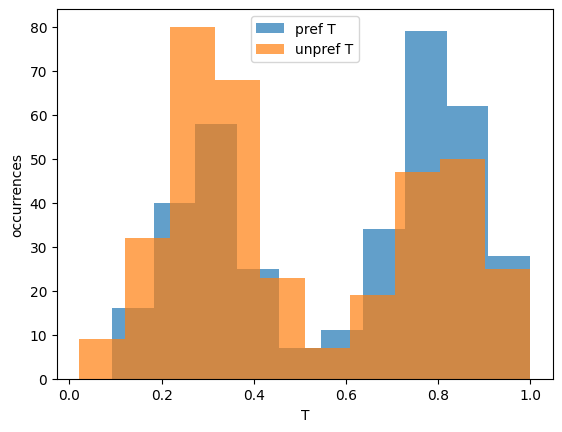

In [ ]:
# extract temperatures
""" ## old FinalResults_FAKE.csv code
temp = pref['(T_A, T_B)']
temperatures = []
for idx in range(len(temp)):
    s = temp.iloc[idx]
    cleaned = re.sub(r'np\.float64\(([^)]+)\)', r'\1', s)
    result = ast.literal_eval(cleaned)
    temperatures.append(result)
"""
# new code
temperatures = []
for idx, row in pref.iterrows():
    temperatures.append((row["T_A"], row["T_B"]))
# extract preferences
preferences = pref["humanChoice"]
temp_index = []
spref_index = []
for idx in range(len(preferences)):
    # B is preferred
    if preferences.iloc[idx].find("Img_A") == -1:
        temp_index.append(1)
        spref_index.append(0)
    # A is preferred
    if preferences.iloc[idx].find("Img_B") == -1:
        temp_index.append(0)
        spref_index.append(1)

# sanity check
print(len(temperatures), len(preferences))

# extract the distribution
pref_temp = np.zeros(len(temperatures))
spref_temp = np.zeros(len(temperatures))

for idx in range(len(pref_temp)):
    pref_temp[idx] = temperatures[idx][temp_index[idx]]
    spref_temp[idx] = temperatures[idx][spref_index[idx]]

# plot logic
plt.hist(pref_temp, alpha=0.7, label="pref T")
plt.hist(spref_temp, alpha=0.7, label="unpref T")
plt.legend()
plt.ylabel("occurrences")
plt.xlabel("T")
plt.show()

### 1.2: Preference exploration

In [ ]:
# Count preferences
cnt = 0
for choice in pref["humanChoice"]:
    if choice.find("Img_A") != -1:
        cnt += 1
tot = len(pref["humanChoice"])
print(f"Img A preferences: {cnt}, in %: {cnt / tot * 100}")
print(
    f"Img B preferences: {len(pref['humanChoice']) - cnt}, in %: {float(len(pref['humanChoice']) - cnt) / tot * 100}"
)

Img A preferences: 145, in %: 40.27777777777778
Img B preferences: 215, in %: 59.72222222222222


In [ ]:
# read the preference
x = []
x_training = []
y_w = []
y_l = []
real = []
real_ab = []

for idx, row in tqdm(pref.iterrows()):
    y_w.append(load_img(row["humanChoice"]))
    y_l.append(load_img(row["rejectionChoice"]))
    x.append(
        preprocess_img(load_img(f"DPO_dataset/Img_true/Real_{row['ImageID']}.png"))[
            1
        ].squeeze()
    )
    x_training.append(
        preprocess_img(load_img(f"DPO_dataset/Img_true/Real_{row['ImageID']}.png"))[1][
            0
        ]
    )
    real_ab.append(
        preprocess_img_ab(load_img(f"DPO_dataset/Img_true/Real_{row['ImageID']}.png"))[
            1
        ]
    )
    real.append(load_img(f"DPO_dataset/Img_true/Real_{row['ImageID']}.png"))

print("Imported lens:", len(x), len(y_w), len(y_l))

0it [00:00, ?it/s]

Imported lens: 360 360 360


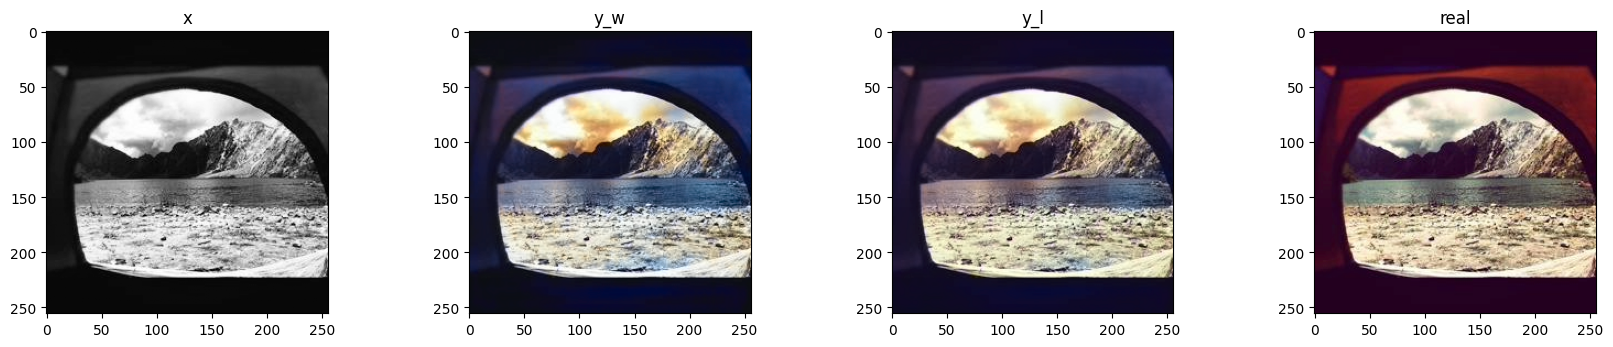

In [ ]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 5))
fig.subplots_adjust(wspace=0.5)

index = 10
ax1.imshow(x[index], cmap="gray")
ax2.imshow(y_w[index])
ax3.imshow(y_l[index])
ax4.imshow(real[index])

ax1.set_title("x")
ax2.set_title("y_w")
ax3.set_title("y_l")
ax4.set_title("real")

plt.show()

In [ ]:
# format the preference dataset as list of dicts of np arrays
samples = [
    {
        "l": x_training[idx],
        "chosen_ab": preprocess_img_ab(y_w[idx])[1],  # element 0 is original-shaped
        "rejected_ab": preprocess_img_ab(y_l[idx])[1],  # element 1 is reshaped
    }
    for idx in range(len(x))
]
# samples[0]

## 2: Distribution evaluation

Explained variance ratio: [0.31982282 0.12609608]


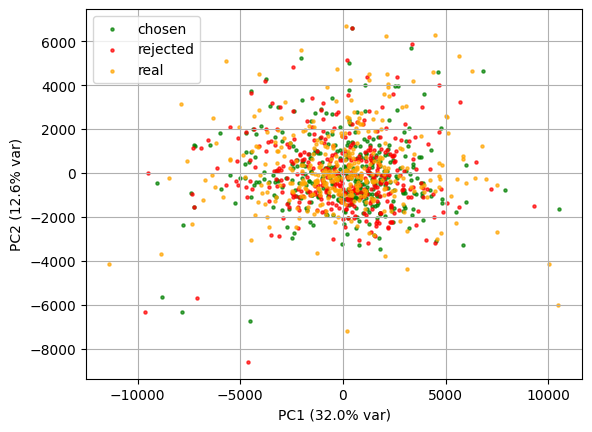

In [ ]:
# Flatten each ab image to a 1D vector (2 * H * W,)
chosen_vecs = [
    samples[idx]["chosen_ab"].numpy().reshape(-1) for idx in range(len(samples))
]
rejected_vecs = [
    samples[idx]["rejected_ab"].numpy().reshape(-1) for idx in range(len(samples))
]
real_vecs = [real_ab[idx].reshape(-1) for idx in range(len(real))]

all_vecs = np.stack(chosen_vecs + rejected_vecs + real_vecs)  # (2N, 2*H*W)

# Fit PCA on all samples together so both sets share the same projection
pca = PCA(n_components=2)
all_2d = pca.fit_transform(all_vecs)

n = len(chosen_vecs)
chosen_2d = all_2d[:n]
rejected_2d = all_2d[n : 2 * n]
real_2d = all_2d[2 * n :]

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
size = 5  # dotsize
plt.scatter(
    chosen_2d[:, 0], chosen_2d[:, 1], c="green", label="chosen", alpha=0.7, s=size
)
plt.scatter(
    rejected_2d[:, 0], rejected_2d[:, 1], c="red", label="rejected", alpha=0.7, s=size
)
plt.scatter(real_2d[:, 0], real_2d[:, 1], c="orange", label="real", alpha=0.7, s=size)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
plt.legend()
plt.grid()
plt.show()

## 3: Retraining part of the model with DPO
First we run a logits check

In [ ]:
# build model takes as input
# - desired model to retrain
# - a list of target layers (we train only the rightmost part of the model, sparing compute time)


model_name = "eccv16"
lora_layers = [
    # "model7.2", "model7.4",   # semantic context
    # "model8.2", "model8.4", "model8.6"
    "model8.6"
]
finetune_layers = []
model = build_model(model_name, lora_layers, finetune_layers, pretrained=True)
model

Downloading: "https://colorizers.s3.us-east-2.amazonaws.com/colorization_release_v2-9b330a0b.pth" to /root/.cache/torch/hub/checkpoints/colorization_release_v2-9b330a0b.pth


100%|██████████| 123M/123M [00:04<00:00, 30.5MB/s]


Frozen: 32,236,011  |  Trainable: 4,552


ECCVGenerator(
  (model1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (model2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (model3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU(inplace=Tru

In [ ]:
# check for shapes
sample = samples[0]
print(sample["l"].shape)  # expect (1, 256, 256)
print(sample["chosen_ab"].shape)  # expect (2, 256, 256)
print(sample["rejected_ab"].shape)  # expect (2, 256, 256)
print("total datapoints:", len(samples))

torch.Size([1, 256, 256])
torch.Size([2, 256, 256])
torch.Size([2, 256, 256])
total datapoints: 360


In [ ]:
with torch.no_grad():
    sample = samples[0]
    cb = ab_to_bin_indices(sample["chosen_ab"][None] / 110.0, pts)
    rb = ab_to_bin_indices(sample["rejected_ab"][None] / 110.0, pts)
    print(f"Pixel con bin diverso: {(cb != rb).float().mean() * 100:.1f}%")

# meglio ancora, su tutto il dataset:
diffs = []
for s in samples:
    cb = ab_to_bin_indices(s["chosen_ab"][None] / 110.0, pts)
    rb = ab_to_bin_indices(s["rejected_ab"][None] / 110.0, pts)
    diffs.append((cb != rb).float().mean().item())
print(
    f"Media pixel diversi: {np.mean(diffs) * 100:.1f}%  min: {min(diffs) * 100:.1f}%  max: {max(diffs) * 100:.1f}%"
)

Pixel con bin diverso: 58.7%
Media pixel diversi: 46.8%  min: 1.8%  max: 99.5%


In [ ]:
# train function handles automatically the loss and the data
# original model is the standard model that DPO uses as reference
import matplotlib.pyplot as plt

original_model = eccv16(pretrained=True).eval()
lora_model = build_model("eccv16", lora_layers, finetune_layers)
batch_size = 15
lr = 1e-5
beta = 0.01
test_size = 0.15
val_every = 5
saving_epochs = [10, 50, 100]

file_name = Path("dpo_trained_020526.pth")
training = True

if not file_name.exists():
    file_name.touch()

if training:
    print("training model...")
    new_model = train(
        lora_model,
        original_model,
        lora_layers,
        finetune_layers,
        samples,
        saving_epochs[-1],
        batch_size,
        lr,
        beta,
        test_size,
        val_every,
        saving_epochs,
    )

    torch.save(new_model.state_dict(), file_name)
else:
    new_model = build_model(model_name, lora_layers, finetune_layers, pretrained=False)
    new_model.load_state_dict(torch.load(file_name, map_location="cpu"))
    print("Loaded model!")

training model...
Dataset split — Train: 306  |  Val: 54
Ref LL chosen=-139861.1094  rejected=-140393.0312  gap=531.9219


Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1/30 [train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 2/30 [train]:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 3/30 [train]:   0%|          | 0/21 [00:00<?, ?it/s]

...

Epoch  20/30  train=0.6779  lr=2.58e-06


Epoch 20/30 [val]:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch  20/30  train=0.6779  val=0.6768  win=31.5%  margin=-223.91  r_c=-0.024  r_r=-0.059  lr=2.58e-06


Epoch 21/30 [train]:   0%|          | 0/21 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
import torch

# Save the state_dict of the new_model
torch.save(new_model.state_dict(), f"DPO_lora_{beta}_{lr}_1505.pth")
print(f"Model parameters saved to {DPO_lora_{beta}_{lr}_1505.pth}")

NameError: name 'save_path' is not defined

# Hyperparameter search

- learning rate: [1e-3, 1e-4, 1e-5]
- epochs: [10, 50, 100]
- layers: 
- beta: []
- rank
